# 문자 단위 GPT 실습 (한국어)

김유정 단편 corpus로 문자 단위 GPT를 학습하며 Transformer 구조를 확인함

- 데이터: 위키문헌 퍼블릭 도메인 김유정 단편 8편 (텍스트 파일 1개, 다운로드 후 업로드해서 사용)
- 코드: Andrej Karpathy의 [minGPT](https://github.com/karpathy/minGPT) (MIT License) 를 교육용으로 단순화해서 이 노트북 안에 직접 포함함 (외부 저장소 clone 없이 노트북 파일 하나로 실행 가능)


표시 기준

- [필수 이해] : 꼭 이해하고 넘어가야 하는 부분, 보고서에도 필요함
- [개념 확인] : 알아두면 좋은 부분, 자세히 몰라도 실습은 진행 가능
- [참고 코드] : 구현 세부사항, 그냥 넘어가도 무방함


## 1. 환경 준비

In [1]:
import os              # 파일 존재 여부 확인 등 운영체제 기능
import math            # 제곱근·로그 등 수학 함수
import time            # 학습 시간 측정
import random          # 파이썬 기본 난수 생성기
from dataclasses import dataclass      # @dataclass: __init__ 없이 필드만 선언해도 되는 설정용 클래스 문법
from collections import defaultdict    # 없는 key로 접근해도 자동으로 기본값(list 등)을 만들어주는 dict

# 외부 라이브러리 import
import numpy as np                                    # 수치 연산 라이브러리
import torch                                          # 딥러닝 프레임워크 (텐서 연산 + 자동 미분)
import torch.nn as nn                                 # 신경망 레이어(Linear, LayerNorm 등) 모듈
from torch.nn import functional as F                  # softmax, cross_entropy 등 함수형 연산
from torch.utils.data import Dataset                  # 커스텀 데이터셋을 만들 때 상속받는 기본 클래스
from torch.utils.data.dataloader import DataLoader    # Dataset을 배치 단위로 잘라서 공급해주는 클래스
import matplotlib.pyplot as plt                       # 그래프(loss 곡선 등) 그리기용


def set_seed(seed):
    """실험 재현을 위한 랜덤 시드 고정"""
    # 서로 다른 난수 생성기로, 하나씩 다 고정해야 실행할 때마다 같은 결과가 나옴
    random.seed(seed)                 # 파이썬 기본 random 모듈
    np.random.seed(seed)              # numpy 난수
    torch.manual_seed(seed)           # torch CPU 연산 난수
    torch.cuda.manual_seed_all(seed)  # torch GPU 연산 난수 (GPU가 없으면 그냥 무시됨)


print("PyTorch:", torch.__version__)                 # 설치된 PyTorch 버전 확인
print("CUDA available:", torch.cuda.is_available())  # GPU(CUDA) 사용 가능 여부 확인


PyTorch: 2.13.0
CUDA available: False


## 2. 실험 설정 (모델·학습·생성·데이터·causal mask를 한 곳에서 관리)

In [2]:
# ===== 실험 설정: 아래 값만 바꿔가며 재실행 =====
# (모델 크기 / 학습 반복 수 / 문맥 길이 / 생성 파라미터 / 데이터 양 / causal mask 를 한 곳에서 관리)
# 기존에 각 값이 어디에 흩어져 있었는지는 노트북 맨 끝 "리팩토링 보고서" 셀 참고
# 변수명이 전부 대문자인 이유: 파이썬 관례상 "실행 중에 값이 안 바뀌는 상수"는 ALL_CAPS로 씀 (강제 규칙은 아니고 약속임)

# 1) 모델 크기 (기존: 5.1 GPTConfig 안에서 직접 수정)
N_LAYER = 12            # Transformer Block 수
N_HEAD = 3              # Attention 헤드 수
N_EMBD = 192            # 임베딩 벡터 차원

# 2) 학습 반복 수 (기존: FAST_RUN True/False 두 프리셋 중 선택)
MAX_ITERS = 450         # 총 학습 스텝 수 (100 / 500 / 2000 등으로 비교)
SAMPLE_EVERY = 50       # 몇 iter마다 중간 생성 결과를 출력할지
SAMPLE_LENGTH = 200     # 중간 생성 결과 길이 (글자 수)

# 3) 문맥 길이 (기존: 4번 CharDataset 생성 시 block_size=128로 직접 지정)
BLOCK_SIZE = 64        # 한 번에 볼 수 있는 최대 문맥 길이

# 4) 생성 파라미터 (기존: 7·8·10번 generate() 호출마다 각각 하드코딩)
TEMPERATURE = 1.0       # 낮추면 안정적·뻔한 문장, 높이면 다양한 문장
TOP_K = 10              # 상위 k개 문자만 후보로 삼아 샘플링

# 5) 데이터 양 (기존: 없음 — corpus 전체를 항상 사용)
DATA_FRACTION = 1.0     # 1.0 = corpus 전체, 0.5 = 앞쪽 절반만 사용

# 6) causal mask 사용 여부 (기존: Block 클래스 안에서 CausalSelfAttention으로 고정)
USE_CAUSAL_MASK = True  # False로 하면 SelfAttention(마스크 없음)으로 동작

set_seed(3407)
# 이 셀 맨 아래에서 set_seed를 호출하는 이유: 아래쪽에서 모델 가중치를 무작위로 초기화하기 전에
# 미리 시드를 고정해둬야, 위 설정값을 그대로 두고 다시 실행했을 때 항상 같은 결과가 나옴


## 3. 데이터 준비 (김유정 단편)

위키문헌 퍼블릭 도메인 작품 8편을 정제·병합한 corpus

1. 아래 링크에서 input_kr.txt 파일 다운로드: [input_kr.txt 다운로드](https://raw.githubusercontent.com/mue76/skala-llm-transformer/main/input_kr.txt)
2. 다음 셀 실행 → 파일 선택 창에서 방금 받은 input_kr.txt 업로드


In [3]:
DATA_PATH = "input_kr.txt"

# os.path.exists(): 해당 경로에 파일이 있는지 True/False로 알려주는 표준 라이브러리 함수
if not os.path.exists(DATA_PATH):
    # 로컬에 파일이 없을 때만 이 블록이 실행됨 — Colab에서만 동작하는 파일 업로드 기능
    from google.colab import files                        # Colab 환경에서만 제공되는 모듈 (로컬에서는 import 자체가 안 됨)
    print(f"'{DATA_PATH}' 파일 선택 후 업로드")            # f-string: 문자열 안 {} 자리에 변수 값을 바로 넣는 문법
    uploaded = files.upload()                             # 업로드 창을 띄우고, {파일명: 내용} 형태의 dict를 반환
    assert DATA_PATH in uploaded, f"'{DATA_PATH}' 파일 업로드 필요"  # assert 조건, 메시지 : 조건이 거짓이면 메시지와 함께 에러를 냄

# with open(...) as f: 블록이 끝나면 파일이 자동으로 닫힘 (닫기를 깜빡할 걱정이 없음)
with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()  # 파일 전체 내용을 문자열 하나로 읽어옴

text = text[:int(len(text) * DATA_FRACTION)]  # DATA_FRACTION만큼만 사용 (설정은 2번 셀)
# text[:n] : 문자열 앞에서부터 n글자만 잘라내는 슬라이싱. 인덱스는 정수여야 하므로 int(...)로 감쌈

print(f"전체 문자 수: {len(text):,}")   # f-string의 :, 옵션 → 숫자를 천 단위 콤마로 표시
print(f"고유 문자 수: {len(set(text))}")  # set(text): 문자열을 중복 없는 문자 집합으로 바꿔서 개수를 셈 - 중복이 제거된 전체 문자
print(text[:300])                        # 앞 300글자만 미리보기


전체 문자 수: 97,709
고유 문자 수: 1272
﻿오늘도 또 우리 수탉이 막 쫓기었다. 내가 점심을 먹고 나무를 하러 갈 양으로 나올 때이었다. 산으로 올라서려니까 등뒤에서 푸드득푸드득, 하고 닭의 횃소리가 야단이다. 깜짝 놀라서 고개를 돌려보니 아니나다르랴, 두 놈이 또 얼리었다.
점순네 수탉(은 대강이가 크고 똑 오소리같이 실팍하게 생긴 놈)이 덩저리 작은 우리 수탉을 함부로 해내는 것이다. 그것도 그냥 해내는 것이 아니라 푸드득하고 면두를 쪼고 물러섰다가 좀 사이를 두고 푸드득하고 모가지를 쪼았다. 이렇게 멋을 부려 가며 여지없이 닦아 놓는다. 그러면 이 못생긴 것은 쪼일 


## 4. 문자 토큰화와 CharDataset  [필수 이해] 문자 토큰화

- 토큰 = 문자 1개. stoi는 문자를 정수로, itos는 정수를 문자로 바꿔줌
- 입력 x = 128글자, 정답 y = 한 글자씩 밀린 128글자
- 과제: 모든 위치에서 다음 문자 맞히기


In [4]:
class CharDataset(Dataset):  # torch의 Dataset을 상속 → DataLoader가 배치로 잘라 쓸 수 있는 형태가 됨
    """corpus를 (입력 x, 정답 y) 문자 배치로 잘라 공급."""

    def __init__(self, data, block_size=128):  
        chars = sorted(list(set(data)))          # 고유 문자 목록 = vocab
        # set(data): 중복 제거 → list(...): 리스트로 변환 → sorted(...): 정렬해서 순서를 항상 동일하게 고정
        self.vocab_size = len(chars)
        self.block_size = block_size
        self.data = data

        self.stoi = {ch: i for i, ch in enumerate(chars)}  # 문자 → 정수
        self.itos = {i: ch for i, ch in enumerate(chars)}  # 정수 → 문자
        # {키: 값 for ... in ...} = 딕셔너리 컴프리헨션 (for문으로 딕셔너리를 한 줄에 생성하는 문법)
        # enumerate(chars): chars의 각 원소를 (인덱스, 값) 쌍으로 순회하게 해줌

        print(f"데이터 {len(data):,}자, 고유 문자 {self.vocab_size:,}개")

    def __len__(self):  # __len__: len(dataset)을 호출했을 때 실행되는 함수 (파이썬 매직 메서드)
        return len(self.data) - self.block_size
        # 전체 길이에서 block_size를 뺀 이유: __getitem__에서 idx+block_size+1까지 잘라야 하므로
        # 데이터 맨 끝 근처 idx가 범위를 벗어나지 않도록 미리 여유를 둠

    def __getitem__(self, idx):  # __getitem__: dataset[idx]로 접근할 때 실행되는 함수 (DataLoader가 내부에서 자동으로 호출)
        # block_size+1 글자를 잘라 정수로
        chunk = self.data[idx : idx + self.block_size + 1]  # 문자열 슬라이싱: idx부터 idx+block_size+1 직전까지
        dix = [self.stoi[s] for s in chunk]
        # [... for s in chunk] = 리스트 컴프리헨션. chunk의 각 문자를 정수로 바꿔 리스트로 모음

        x = torch.tensor(dix[:-1], dtype=torch.long)  # 입력
        y = torch.tensor(dix[1:], dtype=torch.long)   # 한 칸 밀린 정답
        # dix[:-1]: 마지막 글자를 뺀 나머지, dix[1:]: 첫 글자를 뺀 나머지 → 정수 리스트를 torch.tensor로 변환
        # dtype=torch.long: 정수형 텐서로 지정 (분류 문제의 정답 인덱스를 표현하려면 정수여야 함)
        return x, y  # 함수가 값 두 개를 반환하면 파이썬에서는 튜플 (x, y)로 자동 묶임


train_dataset = CharDataset(text, block_size=BLOCK_SIZE)

데이터 97,709자, 고유 문자 1,272개


In [5]:
# [필수 이해] 입력 x와 정답 y
# 토큰화 확인: 같은 문자 → 항상 같은 정수
for ch in text[:5]:  # 앞 5글자만 순회 (text[:5] 슬라이싱)
    print(f"'{ch}' → {train_dataset.stoi[ch]}")

x_sample, y_sample = train_dataset[0]  # train_dataset[0] → 내부적으로 __getitem__(0)이 호출되어 (x, y) 튜플을 반환받아 두 변수에 나눠 담음
print("\nx shape:", x_sample.shape, "/ y shape:", y_sample.shape)  # .shape: 텐서의 각 차원 크기를 보여주는 속성
print("\n입력 x :", "".join(train_dataset.itos[int(i)] for i in x_sample[:40]))
print("정답 y :", "".join(train_dataset.itos[int(i)] for i in y_sample[:40]))
# "".join(... for i in x_sample[:40]) : 괄호 안은 제너레이터 표현식 — 문자를 하나씩 만들어내고, "".join(...)이 이어붙여 문자열로 합침
# int(i): 텐서 원소(0차원 텐서)를 파이썬 기본 정수로 변환


'﻿' → 1269
'오' → 836
'늘' → 272
'도' → 316
' ' → 1

x shape: torch.Size([64]) / y shape: torch.Size([64])

입력 x : ﻿오늘도 또 우리 수탉이 막 쫓기었다. 내가 점심을 먹고 나무를 하러 갈
정답 y : 오늘도 또 우리 수탉이 막 쫓기었다. 내가 점심을 먹고 나무를 하러 갈 


## 5. Transformer 아키텍처

| 구성 요소 | 역할 | 구분 |
|---|---|---|
| GPTConfig | 모델 크기 설정 (6층, 6헤드, 192차원) | 설정 |
| SelfAttention | Self-Attention의 핵심 로직 — 어디를 참조할지 계산 (인코더형, 마스크 없음) | 개념 확인 |
| CausalSelfAttention | SelfAttention을 상속 + 미래 위치를 가리는 causal mask만 추가 (GPT/디코더형) | 필수 이해 |
| Block | Attention + MLP | 개념 확인 |
| GPT | 임베딩 → Block×6 → 다음 문자 확률 | 필수 이해 |


### 5.1 모델 설정 (GPTConfig)


In [6]:
@dataclass  # @dataclass: __init__을 직접 안 써도 아래 필드들을 인자로 받는 생성자를 자동으로 만들어주는 데코레이터
class GPTConfig:
    # 필드명: 타입 = 기본값  형태. 타입(int, float, bool)은 사람이 읽기 위한 힌트일 뿐, 파이썬이 강제로 검사하지는 않음
    vocab_size: int            # 고유 문자 수 (데이터에서 결정)
    block_size: int = 128      # 한 번에 볼 수 있는 최대 문맥 길이
    n_layer: int = 6           # Transformer Block 수      (gpt-mini)
    n_head: int = 6            # Attention 헤드 수          (gpt-mini)
    n_embd: int = 192          # 임베딩 벡터 차원           (gpt-mini)
    embd_pdrop: float = 0.1    # 이하 dropout 비율 (과적합 완화)
    resid_pdrop: float = 0.1
    attn_pdrop: float = 0.1
    use_causal_mask: bool = True  # False면 SelfAttention(마스크 없음) 사용 — 설정은 2번 셀

### 5.2 Self-Attention — Transformer의 핵심  [개념 확인] Q, K, V / Multi-Head Attention

Self-Attention은 각 위치가 문장 안의 다른 위치들과 얼마나 관련 있는지 계산해서,
그 관련도(가중치)만큼 정보를 섞어주는 장치. Transformer를 Transformer답게 만드는 핵심 연산임.

1. 입력에서 Query, Key, Value 생성
2. Query·Key 내적으로 관련도 점수 계산
3. softmax로 점수를 확률(가중치)로 변환
4. 그 가중치로 Value를 가중합

BERT 같은 인코더는 이 기본형을 그대로 사용해서 문장 전체(앞뒤 모두)를 자유롭게 참고함.
GPT 같은 디코더는 여기에 미래 위치를 가리는 causal mask 한 가지만 추가함 (다음 셀에서 바로 구현).


In [7]:
# [참고 코드] GELU 구현
class NewGELU(nn.Module):  # nn.Module을 상속받아야 파이토치가 이 클래스를 신경망 레이어로 인식함
    """GPT-2와 같은 GELU 활성화 함수 (tanh 근사식)"""
    def forward(self, x):  # forward: nn.Module을 상속한 클래스에서 실제 연산을 정의하는 메서드. model(x)처럼 호출하면 이 함수가 실행됨
        return 0.5 * x * (1.0 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3.0))
        ))
        # GELU를 정확한 식대로 계산하면 느려서, tanh를 이용한 근사식으로 더 빠르게 계산함 (GPT-2에서 쓰인 방식)


class SelfAttention(nn.Module):
    """멀티헤드 Self-Attention의 핵심 로직 (마스크 없음 = 인코더형)

    모든 위치가 서로(앞뒤 상관없이) 자유롭게 참조 가능한 기본형
    """

    def __init__(self, config):  # config: GPTConfig 객체 하나를 받아서 필요한 값들을 꺼내 씀
        super().__init__()  # 부모 클래스(nn.Module)의 초기화 함수를 먼저 실행 — nn.Module을 상속할 때 항상 지켜야 하는 관례
        assert config.n_embd % config.n_head == 0  # %: 나머지 연산자. 임베딩 차원이 헤드 수로 나누어떨어져야 헤드별로 균등하게 쪼갤 수 있음
        # Q, K, V 를 한 번에 만드는 선형층 (192 → 3×192)
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)  # nn.Linear(입력차원, 출력차원): y = xW + b 형태의 완전연결층 -> 여기에서 W 가중치가 연산됨
        # 헤드 결합 후 출력 선형층
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.attn_dropout = nn.Dropout(config.attn_pdrop)   # nn.Dropout(p): 학습 중 p 확률로 값을 0으로 꺼서 과적합을 줄이는 레이어
        self.resid_dropout = nn.Dropout(config.resid_pdrop)
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def apply_mask(self, att, T):
        """기본 Self-Attention: 마스킹 없음 → 모든 위치를 자유롭게 참조
        (디코더형은 이 메서드만 재정의해서 causal mask 추가)
        """
        return att
        # 이 메서드를 따로 분리해둔 이유: 자식 클래스(CausalSelfAttention)가 이 부분만 오버라이드(재정의)하면
        # 나머지 forward 로직은 그대로 재사용할 수 있기 때문임 (객체지향의 다형성 활용)

    def forward(self, x):
        B, T, C = x.size()  # 배치, 문맥 길이, 임베딩 차원(192)
        # x.size()는 x.shape와 같은 정보를 줌. (B, T, C) 세 값을 한 번에 풀어서 받는 튜플 언패킹

        # [개념 확인] Q, K, V / Multi-Head Attention
        # 1) Q, K, V 생성 후 헤드 6개로 분리: (B, 6, T, 32)
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        # c_attn(x)의 출력은 (B, T, 3*n_embd) → .split(n_embd, dim=2)로 마지막 차원을 n_embd씩 3덩이로 잘라 q, k, v로 나눔
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        # .view(...): 원소 개수는 그대로 두고 텐서 모양만 바꿈 → (B,T,C)를 (B,T,헤드수,헤드별차원)으로 쪼갬
        # .transpose(1, 2): 1번째·2번째 차원을 맞바꿔 (B, 헤드수, T, 헤드별차원) 순서로 만듦 → 헤드마다 따로 연산하기 위함

        # 2) 관련도 점수: (B, nh, T, T)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        # @ : 행렬곱 연산자. q와 k의 마지막 두 차원을 곱해 (T, T) 크기의 위치별 관련도 점수를 만듦
        # k.size(-1)의 제곱근으로 나누는 이유: 차원이 커질수록 내적 값이 커지는 걸 완화(스케일 조정)하기 위함
        # 3) 마스킹 (기본형은 아무 것도 가리지 않음 — 핵심은 여기가 아니라 위/아래 단계)
        att = self.apply_mask(att, T)
        # 4) softmax로 확률화
        att = F.softmax(att, dim=-1)  # 마지막 차원(Key 위치) 기준으로 합이 1이 되는 확률로 변환
        att = self.attn_dropout(att)
        # 5) 가중합: (B, nh, T, 32) → 헤드 결합 (B, T, 192)
        y = att @ v  # 관련도(확률)로 Value를 가중합
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        # transpose로 다시 (B, T, 헤드수, 헤드별차원) 순서로 되돌리고, .contiguous()로 메모리를 재정렬(연속되지 않으면 view가 에러남)
        # 그다음 .view(B, T, C)로 헤드들을 다시 하나로 합침

        y = self.resid_dropout(self.c_proj(y))
        return y


#### GPT는 여기에 causal mask 한 줄만 추가함  [필수 이해] Causal Mask

언어모델은 "다음 문자"를 예측해야 하는데, 미래 문자를 미리 보면 정답을 커닝하는 셈이 됨.
그래서 GPT(디코더)는 SelfAttention을 상속받아 apply_mask만 재정의해서, 각 위치가 자기 자신과 그 이전(과거)만 보게 함.
Q/K/V 생성, softmax, 가중합 등 나머지 로직은 그대로 유지 — 즉 핵심은 여전히 Self-Attention이고, causal mask는 그 위에 얹은 작은 제약 하나일 뿐임.


In [8]:
# [필수 이해] Causal Mask
class CausalSelfAttention(SelfAttention):  # (SelfAttention): SelfAttention 클래스를 상속받아 그 기능을 그대로 물려받음
    """GPT(디코더)용 Self-Attention = SelfAttention + causal mask

    부모 클래스(SelfAttention)와 다른 부분은 딱 두 가지
    1) __init__에서 마스크(하삼각 행렬) 등록
    2) apply_mask 재정의해서 마스크 적용
    """

    def __init__(self, config):
        super().__init__(config)  # 부모(SelfAttention)의 __init__을 먼저 실행해서 c_attn, c_proj 등을 그대로 만듦
        # causal 마스크: 하삼각 행렬 → 각 위치는 자신과 과거만 참조
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
                 .view(1, 1, config.block_size, config.block_size)
        )
        # register_buffer: 학습되지 않는(기울기가 안 흐르는) 고정 텐서를 모델의 일부로 등록 — model.to(device) 할 때 같이 옮겨짐
        # torch.tril(torch.ones(n, n)): n×n 행렬에서 대각선을 포함한 아래쪽만 1, 위쪽은 0인 하삼각 행렬을 만듦
        # .view(1, 1, ...) : SelfAttention.forward의 att 텐서 모양 (B, nh, T, T)와 브로드캐스팅되도록 앞에 차원 2개를 추가

    def apply_mask(self, att, T):  # 부모 클래스의 apply_mask를 같은 이름으로 다시 정의(오버라이드) → forward에서는 이 버전이 호출됨
        # 미래 위치 = -inf → softmax 후 가중치 0
        return att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
        # self.bias[:, :, :T, :T]: 등록해둔 마스크를 실제 문맥 길이 T에 맞게 잘라 씀
        # == 0 인 위치(마스크가 0인, 즉 미래 위치)를 찾아 그 자리의 att 값을 -inf로 채움 (masked_fill)
        # softmax(-inf) = 0이 되므로, 결과적으로 미래 위치는 가중치 0이 되어 전혀 참조되지 않음


왼쪽: SelfAttention(encoder)  — 마스크 없음, 모든 위치를 자유롭게 참조
오른쪽: CausalSelfAttention(GPT) — 미래 위치는 가려짐 (자신+과거만 참조)



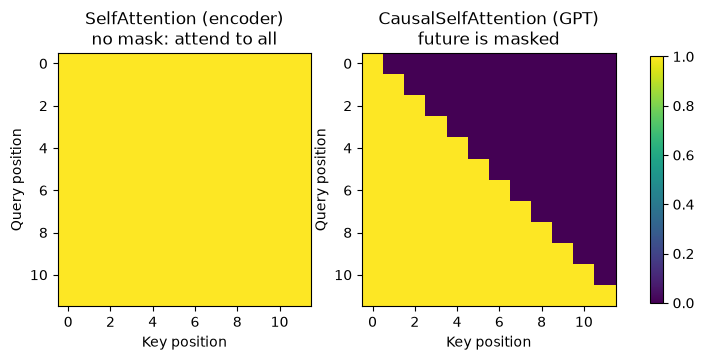

In [9]:
# [필수 이해] Causal Mask (시각화)
# Self-Attention이 참조 가능한 범위 비교: 노란색(1) = 참조 가능, 보라색(0) = 가려짐
print("왼쪽: SelfAttention(encoder)  — 마스크 없음, 모든 위치를 자유롭게 참조")
print("오른쪽: CausalSelfAttention(GPT) — 미래 위치는 가려짐 (자신+과거만 참조)\n")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))  # 1행 2열짜리 그래프 영역(fig)과 그 안의 축(axes) 2개를 한 번에 생성

full_mask = torch.ones(12, 12)                 # SelfAttention(encoder): 마스크 없음
causal_mask = torch.tril(torch.ones(12, 12))   # CausalSelfAttention(GPT)

for ax, m, title in zip(
    axes,
    [full_mask, causal_mask],
    ["SelfAttention (encoder)\nno mask: attend to all",
     "CausalSelfAttention (GPT)\nfuture is masked"],
):
    # zip(axes, [마스크1, 마스크2], [제목1, 제목2]) : 세 개의 목록을 같은 순서끼리 짝지어 동시에 순회
    im = ax.imshow(m, vmin=0, vmax=1)  # imshow: 2차원 행렬을 색깔이 있는 이미지로 그려줌 (vmin/vmax로 색상 범위를 0~1로 고정)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
    ax.set_title(title)

fig.colorbar(im, ax=axes, shrink=0.8)  # 옆에 색-값 대응표(컬러바)를 붙여줌
plt.show()


### 5.3 Transformer Block  [개념 확인] Residual Connection · LayerNorm · MLP

Attention과 MLP를 잔차 연결로 쌓은 한 층, 6번 반복


In [10]:
class Block(nn.Module):
    """Transformer Block = LayerNorm → Attention → LayerNorm → MLP."""

    def __init__(self, config):
        super().__init__()
        # [개념 확인] LayerNorm
        self.ln_1 = nn.LayerNorm(config.n_embd)  # nn.LayerNorm: 각 위치의 벡터를 평균 0, 분산 1 근처로 정규화해 학습을 안정시키는 레이어
        self.attn = CausalSelfAttention(config) if config.use_causal_mask else SelfAttention(config)  # 설정은 2번 셀 USE_CAUSAL_MASK
        # A if 조건 else B : 삼항 표현식. 조건이 참이면 A, 거짓이면 B를 선택 — 한 줄로 if/else를 대신함
        self.ln_2 = nn.LayerNorm(config.n_embd)
        # [개념 확인] MLP
        self.mlp = nn.ModuleDict(dict(
            c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd),  # 192→768
            c_proj  = nn.Linear(4 * config.n_embd, config.n_embd),  # 768→192
            act     = NewGELU(),
            dropout = nn.Dropout(config.resid_pdrop),
        ))
        # nn.ModuleDict: 레이어들을 이름(key)으로 묶어 보관하는 컨테이너. dict(키=값, ...)는 딕셔너리를 만드는 또 다른 문법
        m = self.mlp
        self.mlpf = lambda x: m.dropout(m.c_proj(m.act(m.c_fc(x))))
        # lambda 인자: 식  → 이름 없는 한 줄짜리 함수. c_fc→act→c_proj→dropout 순서로 잇는 MLP 전체를 함수 하나로 미리 만들어둠

    def forward(self, x):
        # [개념 확인] Residual Connection
        x = x + self.attn(self.ln_1(x))   # 잔차 연결 1: 문맥 참조
        x = x + self.mlpf(self.ln_2(x))   # 잔차 연결 2: 변환
        # x + f(x) 형태 = 잔차 연결(residual connection). 층이 깊어져도 원래 입력 정보가 그대로 더해져 학습이 잘 되도록 도와줌
        return x


### 5.4 GPT 전체 모델  [필수 이해] Embedding · Logits와 Loss

문자 정수 → 토큰 임베딩 + 위치 임베딩 → Block×6 → 다음 문자 logits

- forward: 정답과의 cross entropy로 loss 계산
- generate: 한 글자씩 이어 붙이는 autoregressive 생성 (여기 안에 참고 코드로 top-k sampling 포함)


In [11]:
class GPT(nn.Module):
    """GPT 언어 모델."""

    def __init__(self, config):
        super().__init__()
        self.block_size = config.block_size

        # [필수 이해] Embedding
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),  # 토큰 임베딩
            wpe  = nn.Embedding(config.block_size, config.n_embd),  # 위치 임베딩
            drop = nn.Dropout(config.embd_pdrop),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        # nn.Embedding(개수, 차원): 정수 인덱스 하나를 그 차원짜리 벡터로 바꿔주는 조회 테이블(lookup table)
        # nn.ModuleList([... for _ in range(n)]) : 리스트 컴프리헨션으로 Block을 n_layer개 만들어 순서대로 담음. _는 "반복 변수를 안 쓴다"는 관례적 이름
        # 192차원 벡터 → vocab_size개 문자에 대한 점수(logits)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # [참고 코드] 가중치 초기화 (GPT-2 방식: 잔차 projection은 층수로 스케일 조정)
        self.apply(self._init_weights)
        # self.apply(함수): 이 모델 안의 모든 하위 레이어 각각에 대해 함수를 한 번씩 실행해줌 (재귀적으로 전부 순회)
        for pn, p in self.named_parameters():
            if pn.endswith("c_proj.weight"):
                torch.nn.init.normal_(
                    p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer)
                )
        # named_parameters(): (파라미터 이름, 텐서) 쌍을 전부 순회. pn.endswith(...)로 이름이 "c_proj.weight"로 끝나는 것만 골라
        # 표준편차를 층 수에 맞게 더 작게 잡아 다시 초기화(정규분포 난수로 덮어씀) — 층이 깊어질수록 값이 과하게 커지는 걸 막기 위함

        n_params = sum(p.numel() for p in self.transformer.parameters())
        print("number of parameters: %.2fM" % (n_params / 1e6,))
        # p.numel(): 텐서 안의 원소 개수. sum(제너레이터 표현식)으로 전체 파라미터 개수를 합산
        # "%.2fM" % (값,) : 예전 스타일의 문자열 포맷팅(% 연산자), 소수점 둘째 자리까지 표시

    # [참고 코드] 가중치 초기화
    def _init_weights(self, module):  # self.apply(self._init_weights)에 의해 모델 안의 모든 module에 대해 한 번씩 자동으로 호출됨
        if isinstance(module, nn.Linear):  # isinstance(객체, 타입): 객체가 그 타입(또는 하위 타입)인지 확인하는 함수
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)  # 이름 끝에 _가 붙은 함수(normal_)는 텐서를 새로 만들지 않고 그 자리에서 값을 바꿈(in-place)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)

    def forward(self, idx, targets=None):  # targets=None: 기본값이 있는 매개변수 → 호출할 때 안 넘기면 자동으로 None (추론 시에는 정답이 없으므로)
        device = idx.device  # 입력 텐서가 올라가 있는 장치(cpu/cuda)를 그대로 사용 (모델과 데이터의 장치를 맞추기 위함)
        b, t = idx.size()
        assert t <= self.block_size, \
            f"Cannot forward sequence of length {t}, block size is only {self.block_size}"
        # 줄 끝의 \ : 코드 한 줄이 너무 길 때 다음 줄로 이어 쓰겠다는 표시 (파이썬의 줄 연결 문법)
        pos = torch.arange(0, t, dtype=torch.long, device=device).unsqueeze(0)
        # torch.arange(0, t): 0, 1, 2, ..., t-1 순서의 위치 인덱스 텐서를 생성
        # .unsqueeze(0): 맨 앞에 크기 1짜리 차원을 추가해 (t,) → (1, t)로 만듦 (배치 차원과 모양을 맞추기 위함)

        # [필수 이해] Embedding
        # 1) 임베딩: 문자 정수 → 벡터, 위치 정보 더하기
        tok_emb = self.transformer.wte(idx)   # (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos)   # (1, t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        # tok_emb과 pos_emb은 모양이 (b,t,n_embd)와 (1,t,n_embd)로 다르지만, 더하면 브로드캐스팅되어 배치의 모든 샘플에 위치 정보가 똑같이 더해짐
        # 2) Transformer Block 6개 통과
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        # [필수 이해] Logits와 Loss
        # 3) 각 위치에서 "다음 문자" 점수 계산
        logits = self.lm_head(x)              # (b, t, vocab_size)

        # 학습 시: 정답 y와의 cross entropy = loss
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1,
            )
            # cross_entropy는 (샘플 수, 클래스 수) 형태를 기대하므로, .view(-1, ...)로 배치·문맥 차원을 한 줄로 펼침
            # -1은 "나머지 값에 맞춰 자동 계산하라"는 의미의 자리표시자
        return logits, loss

    @torch.no_grad()  # 데코레이터: 이 함수 안에서는 기울기(gradient) 계산을 하지 않음 → 추론 전용이라 메모리·속도에 유리
    def generate(self, idx, max_new_tokens, temperature=1.0,
                 do_sample=False, top_k=None):
        """한 글자씩 예측해 이어 붙이는 autoregressive 생성."""
        for _ in range(max_new_tokens):  # max_new_tokens번 반복하며 한 글자씩 생성
            # 문맥이 block_size 초과 시 뒤쪽만 사용
            idx_cond = idx if idx.size(1) <= self.block_size \
                       else idx[:, -self.block_size:]
            # idx[:, -self.block_size:] : 모든 배치(:)에 대해 마지막 block_size개 위치만 슬라이싱
            logits, _ = self(idx_cond)
            # 마지막 위치의 logits만 사용 (다음 문자 예측)
            logits = logits[:, -1, :] / temperature
            # temperature로 나누면: 1보다 크면 분포가 평평해져(다양성↑), 1보다 작으면 뾰족해짐(확신↑)
            # [참고 코드] Top-k Sampling 구현
            # top_k: 상위 k개 문자만 후보로
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)  # torch.topk: 값이 큰 순서로 top_k개의 (값, 인덱스)를 반환
                logits[logits < v[:, [-1]]] = -float("Inf")
                # v[:, [-1]] : top_k개 중 가장 작은 값(컷오프 기준). 그보다 작은 logits는 전부 -inf로 눌러서 후보에서 제외
            # softmax → 확률분포 → 샘플링
            probs = F.softmax(logits, dim=-1)
            if do_sample:
                idx_next = torch.multinomial(probs, num_samples=1)  # 확률분포 probs를 따라 무작위로 하나를 뽑음 (매번 다른 결과)
            else:
                _, idx_next = torch.topk(probs, k=1, dim=-1)  # 확률이 가장 높은 문자 하나를 그대로 선택 (항상 같은 결과)
            # 예측한 문자를 붙이고 반복
            idx = torch.cat((idx, idx_next), dim=1)  # torch.cat: 텐서를 이어붙임. 기존 문맥 뒤에 새로 뽑은 글자를 추가
        return idx


### 5.5 모델 생성과 shape 확인

In [12]:
# [필수 이해] Logits와 Loss
model_config = GPTConfig(
    vocab_size=train_dataset.vocab_size,
    block_size=BLOCK_SIZE,
    n_layer=N_LAYER,
    n_head=N_HEAD,
    n_embd=N_EMBD,
    use_causal_mask=USE_CAUSAL_MASK,
)
model = GPT(model_config)  # GPTConfig 인스턴스 하나만 넘기면, GPT.P__init__ 안에서 config.xxx로 필요한 값을 꺼내 씀

logits, loss = model(x_sample[None], y_sample[None])
# x_sample은 (block_size,) 모양의 1차원 텐서 → [None]을 붙이면 맨 앞에 차원이 추가되어 (1, block_size)가 됨 (배치 크기 1짜리 배치로 만듦)
print("입력  x:", tuple(x_sample[None].shape), "(배치, 문맥 길이)")
print("출력 logits:", tuple(logits.shape), "(배치, 문맥 길이, vocab)")
print("학습 전 loss: %.4f" % loss.item())
print("참고: 무작위 예측의 이론값 ln(vocab) = %.4f"
      % math.log(train_dataset.vocab_size))
# loss.item(): 원소 1개짜리 텐서를 순수 파이썬 숫자로 꺼냄. 학습 전 loss가 ln(vocab)에 가깝다면 "완전 무작위 예측과 비슷한 상태"라는 뜻


number of parameters: 5.60M
입력  x: (1, 64) (배치, 문맥 길이)
출력 logits: (1, 64, 1272) (배치, 문맥 길이, vocab)
학습 전 loss: 7.1480
참고: 무작위 예측의 이론값 ln(vocab) = 7.1483


## 6. Trainer 준비  [참고 코드] Trainer 내부 동작

학습 루프(순전파 → loss 계산 → 역전파 → 파라미터 업데이트)를 담당하는 Trainer를
별도 파일/저장소 없이 이 노트북 안에 직접 정의함
(Andrej Karpathy의 minGPT trainer를 교육용으로 단순화한 버전, 로직은 동일)


In [13]:
# [참고 코드] Trainer 내부 동작
@dataclass
class TrainerConfig:
    """학습 설정."""
    device: str = "auto"          # 'auto'면 GPU 우선
    num_workers: int = 0          # Colab 호환
    max_iters: int = 2000
    batch_size: int = 64
    learning_rate: float = 5e-4
    betas: tuple = (0.9, 0.95)
    weight_decay: float = 0.1
    grad_norm_clip: float = 1.0


def configure_optimizers(model, config):
    """AdamW 옵티마이저 생성

    weight decay를 적용할 파라미터(Linear의 weight)와
    적용하지 않을 파라미터(bias, LayerNorm, Embedding)를 분리
    """
    decay = set()      # set(): 중복을 허용하지 않는 집합 자료형. 파라미터 이름을 담아뒀다가 뒤에서 교집합/합집합 검사에 사용
    no_decay = set()
    whitelist_weight_modules = (torch.nn.Linear,)
    blacklist_weight_modules = (torch.nn.LayerNorm, torch.nn.Embedding)
    for mn, m in model.named_modules():        # named_modules(): (모듈 이름, 모듈) 쌍을 전부 순회 (nn.Linear, nn.LayerNorm 등 하나하나)
        for pn, p in m.named_parameters():      # 각 모듈이 직접 갖고 있는 (파라미터 이름, 텐서) 쌍을 순회
            fpn = "%s.%s" % (mn, pn) if mn else pn  # fpn = full parameter name: "모듈이름.파라미터이름" 형태로 합침 (최상위는 모듈이름이 없어 그냥 pn 사용)
            if pn.endswith("bias"):
                no_decay.add(fpn)
            elif pn.endswith("weight") and isinstance(m, whitelist_weight_modules):
                decay.add(fpn)
            elif pn.endswith("weight") and isinstance(m, blacklist_weight_modules):
                no_decay.add(fpn)

    param_dict = {pn: p for pn, p in model.named_parameters()}  # 이름 → 텐서 딕셔너리 (뒤에서 이름으로 다시 텐서를 찾기 위함)
    inter_params = decay & no_decay   # & : 두 집합의 교집합. decay와 no_decay 둘 다에 들어간 이름이 있으면 안 됨 (버그 검증용)
    union_params = decay | no_decay   # | : 두 집합의 합집합. 전체 파라미터가 둘 중 하나에는 반드시 들어가야 함 (누락 검증용)
    assert len(inter_params) == 0, \
        "parameters %s made it into both decay/no_decay sets!" % (str(inter_params),)
    assert len(param_dict.keys() - union_params) == 0, \
        "parameters %s were not separated into either decay/no_decay set!" \
        % (str(param_dict.keys() - union_params),)
    # param_dict.keys() - union_params : 집합 뺄셈으로 "분류가 안 된 파라미터가 있는지"를 확인

    optim_groups = [
        {"params": [param_dict[pn] for pn in sorted(list(decay))],
         "weight_decay": config.weight_decay},
        {"params": [param_dict[pn] for pn in sorted(list(no_decay))],
         "weight_decay": 0.0},
    ]
    # optimizer에 파라미터 그룹을 리스트[딕셔너리, 딕셔너리] 형태로 넘기면, 그룹마다 다른 weight_decay를 적용할 수 있음
    optimizer = torch.optim.AdamW(
        optim_groups, lr=config.learning_rate, betas=config.betas
    )
    return optimizer


class Trainer:
    """단순 학습 루프. GPT에 특화된 내용은 없는 범용 보일러플레이트"""

    def __init__(self, config, model, train_dataset):
        self.config = config
        self.model = model
        self.optimizer = None
        self.train_dataset = train_dataset
        self.callbacks = defaultdict(list)
        # defaultdict(list): 존재하지 않는 key로 접근해도 에러 대신 빈 리스트를 자동으로 만들어줌 (콜백을 append하기 편하게)

        # 학습 장치 결정
        if config.device == "auto":
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
            # A if 조건 else B 삼항 표현식: GPU가 있으면 "cuda", 없으면 "cpu" 문자열을 선택
        else:
            self.device = config.device
        self.model = self.model.to(self.device)  # .to(device): 모델의 모든 파라미터를 해당 장치(CPU/GPU) 메모리로 옮김
        print("running on device", self.device)

        # 로깅용 상태 변수
        self.iter_num = 0
        self.iter_time = 0.0
        self.iter_dt = 0.0

    def set_callback(self, onevent: str, callback):
        self.callbacks[onevent] = [callback]
        # 이벤트 이름(onevent)마다 실행할 함수(callback)를 리스트에 등록 — "이 시점에 이 함수를 불러줘"라고 예약해두는 방식

    def trigger_callbacks(self, onevent: str):
        for callback in self.callbacks.get(onevent, []):
            callback(self)
        # dict.get(key, 기본값): key가 없으면 에러 대신 기본값(여기선 빈 리스트)을 반환 → 등록된 콜백이 없어도 안전하게 넘어감

    def run(self):
        model, config = self.model, self.config  # 한 줄에서 여러 변수를 동시에 할당 (튜플 언패킹)

        # 옵티마이저 준비
        self.optimizer = configure_optimizers(model, config)

        # 데이터로더 준비 (복원추출 랜덤 샘플링)
        train_loader = DataLoader(
            self.train_dataset,
            sampler=torch.utils.data.RandomSampler(
                self.train_dataset, replacement=True, num_samples=int(1e10)
            ),
            shuffle=False,
            pin_memory=torch.cuda.is_available(),
            batch_size=config.batch_size,
            num_workers=config.num_workers,
        )
        # replacement=True: 한 번 뽑은 데이터도 다시 뽑힐 수 있음(복원추출) → 매 iter마다 corpus 전체를 다 안 돌아도 됨
        # num_samples=int(1e10): 사실상 무한히 많이 뽑을 수 있게 큰 수를 넣어둠 (실제 반복 횟수는 아래 max_iters로 직접 제어)

        model.train()  # 모델을 학습 모드로 전환 (Dropout이 실제로 동작하게 됨)
        self.iter_num = 0
        self.iter_time = time.time()
        data_iter = iter(train_loader)  # iter(): DataLoader를 순회할 수 있는 이터레이터로 변환
        while True:  # 무한 루프 — 아래 종료 조건(break)에서만 빠져나감

            # 다음 배치 (x, y) 가져오기
            try:
                batch = next(data_iter)  # next(): 이터레이터에서 다음 값을 하나 꺼냄
            except StopIteration:  # 이터레이터가 바닥나면 StopIteration 예외가 발생함 → 새로 만들어서 이어서 사용
                data_iter = iter(train_loader)
                batch = next(data_iter)
            batch = [t.to(self.device) for t in batch]  # 리스트 컴프리헨션으로 배치 안의 모든 텐서를 학습 장치로 옮김
            x, y = batch

            # 순전파: 예측과 loss 계산
            _, self.loss = model(x, y)  # model(x, y)는 (logits, loss) 튜플을 반환 — logits는 여기서 안 쓰므로 _로 버림

            # 역전파: 기울기 계산 후 파라미터 갱신
            model.zero_grad(set_to_none=True)  # 이전 iter에서 쌓인 기울기를 초기화 (set_to_none=True가 메모리·속도 면에서 더 효율적)
            self.loss.backward()  # loss를 기준으로 모든 파라미터에 대한 기울기(gradient)를 자동으로 계산
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), config.grad_norm_clip
            )
            # 기울기 크기가 너무 커지지 않도록 최대치를 제한(clipping) — 학습이 갑자기 발산하는 것을 방지
            self.optimizer.step()  # 계산된 기울기를 이용해 실제로 파라미터 값을 한 스텝 업데이트

            self.trigger_callbacks("on_batch_end")  # 배치 하나가 끝날 때마다 등록된 콜백(예: loss 기록, 중간 생성) 실행
            self.iter_num += 1
            tnow = time.time()
            self.iter_dt = tnow - self.iter_time
            self.iter_time = tnow

            # 종료 조건
            if config.max_iters is not None and self.iter_num >= config.max_iters:
                break


In [14]:
trainer_config = TrainerConfig(max_iters=MAX_ITERS)
trainer = Trainer(trainer_config, model, train_dataset)
# Trainer(config, model, dataset) 호출 → 위에서 정의한 Trainer.__init__(self, config, model, train_dataset)가 실행되어 인스턴스가 만들어짐

running on device cpu


## 7. 학습 전 생성 결과  [필수 이해] 학습 전후 생성 결과


In [15]:
context = text[:16]  # corpus 맨 앞 16글자를 생성의 시작 문맥(prompt)으로 사용

x_context = torch.tensor(
    [train_dataset.stoi[s] for s in context],
    dtype=torch.long
)[None, ...].to(trainer.device)
# [train_dataset.stoi[s] for s in context] : 리스트 컴프리헨션으로 각 글자를 정수로 변환
# [None, ...] : 맨 앞에 차원 하나 추가(배치 차원). ...(Ellipsis)은 "나머지 차원은 그대로 두라"는 의미

model.eval()  # 모델을 평가/추론 모드로 전환 (Dropout이 꺼져서 항상 같은 방식으로 동작)
with torch.no_grad():  # 이 블록 안에서는 기울기 계산을 하지 않음 (추론만 할 거라 메모리를 아낌)
    generated = model.generate(
        x_context, 300, temperature=TEMPERATURE, do_sample=True, top_k=TOP_K
    )[0]
    # generate()는 (배치, 길이) 모양을 반환하므로 [0]으로 배치의 첫 번째(유일한) 샘플만 꺼냄

before_training = "".join(train_dataset.itos[int(i)] for i in generated)
print(before_training)

오늘도 또 우리 수탉이 막 푼편숴밑쏟맵벅십찌캔글끈꼴맵2왱꼼향싶탄괘끙멩릎냇락줴낼야놈똥흩깃맵핑정깃챈툰칫뽐적깔문칠정끈흙셨체개빵꿇잰빵끝윗둔숙깃십잰바떼왔빵꿇광탉빵얹랐째퍼덜기량릉째~퍼툇능상틀숙빵놨퐁낡잰탈분본퐁둔봬얘뻥얹랐한총“벤숙껑잰잰탈엌빌씻띄잰“퍼2몰째~홀칫헤녔빵웃바탈댁잰잰갯얘뻥한쪽순쪼싹빵웃홀던꿇빵꿇마빵빛잰끝﻿째순훌꿇퍼빵빵얹훅“벤잰2울맸끝앨빛“얹랐얘잰끝체끝잰체룽코얘퐁볶끝처굉심순﻿땅랐뻥덩떤빵흡윤'곡한줏체념빵빵씻굉꿇낟꿇눅“얹퍼2끝탈툇~덜홀퍼잰“곡풍섬승떤끅잰끝코씬캑“엮빵얹훅앗랐랐길떼홉속짹꿇눅끝냇핏앗툽얘터슴멀얘끝잰갯째털칫빵껑빵흡꿀석염코얘퐁냇퍼얹독퐁태퐁몇쭉잰펑총냇퍼석밖잰갯봬룽빵


## 8. 학습

500 iter마다 중간 생성 결과 출력


In [16]:
loss_history = []        # iter마다의 loss 값을 순서대로 쌓아둘 리스트
generation_history = {}  # {iter 번호: 생성 결과} 형태로 중간 결과를 저장할 딕셔너리
start_time = time.time()

def batch_end_callback(trainer):  # trainer.set_callback("on_batch_end", ...)으로 등록되면, 배치 하나가 끝날 때마다 trainer 자신을 인자로 받아 호출됨
    loss_history.append(float(trainer.loss.item()))

    if trainer.iter_num % 10 == 0:  # %: 나머지 연산자 → 10의 배수인 iter에서만 조건이 참이 됨
        print(
            f"iter_dt {trainer.iter_dt * 1000:.2f}ms; "
            f"iter {trainer.iter_num}: "
            f"train loss {trainer.loss.item():.5f}"
        )
        # :.2f / :.5f : f-string에서 소수점 자릿수를 지정하는 포맷 옵션

    if trainer.iter_num > 0 and trainer.iter_num % SAMPLE_EVERY == 0:
        model.eval()
        with torch.no_grad():
            y = model.generate(
                x_context, SAMPLE_LENGTH,
                temperature=TEMPERATURE, do_sample=True, top_k=TOP_K
            )[0]
        completion = "".join(train_dataset.itos[int(i)] for i in y)
        generation_history[trainer.iter_num] = completion  # 딕셔너리에 iter 번호를 key로 생성 결과를 저장
        print("\n" + "=" * 80)  # "=" * 80 : 문자열을 80번 반복해 구분선을 만듦
        print(f"[iter {trainer.iter_num} 생성 결과]")
        print(completion)
        print("=" * 80 + "\n")
        model.train()  # 중간 생성이 끝났으니 다시 학습 모드로 전환 (Dropout 다시 켜짐)

trainer.set_callback("on_batch_end", batch_end_callback)  # 위에서 정의한 함수를 "on_batch_end" 이벤트에 등록
trainer.run()  # 실제 학습 루프 시작 — 내부에서 매 배치 끝마다 batch_end_callback이 호출됨

elapsed_time = time.time() - start_time
print(f"학습 시간: {elapsed_time:.1f}초")
print(f"최종 loss: {loss_history[-1]:.5f}")  # 리스트의 마지막 원소는 인덱스 -1로 접근

iter_dt 0.00ms; iter 0: train loss 7.18851
iter_dt 427.61ms; iter 10: train loss 5.44123
iter_dt 380.71ms; iter 20: train loss 4.79756
iter_dt 362.55ms; iter 30: train loss 4.50791
iter_dt 362.00ms; iter 40: train loss 4.30777
iter_dt 344.19ms; iter 50: train loss 4.24193

[iter 50 생성 결과]
﻿오늘도 또 우리 수탉이 막 나 그 아이이 다
아 나 내다. 나 그 그 그를 이다.
하이 나 아다.고 그다. 아이 이 하에 이는 하이 아다, 아다. 그 내고 하. 한 아에, 아다. 아 그 
그 것리에, 내고 아 그 그다. 그 다.가 아이, 이다. 내고 그 하고 
나 나는 하고 아고 나, 그 그 내은, 하 내 한 하고다. 그 하 아다가 한 다
다
그 어지는 하다 하에 하이 내이 하에 


iter_dt 336.48ms; iter 60: train loss 4.08265
iter_dt 334.77ms; iter 70: train loss 4.08265
iter_dt 333.82ms; iter 80: train loss 3.94348
iter_dt 381.61ms; iter 90: train loss 3.96448
iter_dt 341.55ms; iter 100: train loss 3.88416

[iter 100 생성 결과]
﻿오늘도 또 우리 수탉이 막 아니 그리고 그 것이, 아니 그를 그를 일어서 사고 나서지 그 것 그러 내었다. 그 아서도 것이서 그는 아내는서 그리어서 내고 그리 내는 하는
그리게. 사리고 것 그 아 사어서 일이었게 못이 이는 그리 아내어 아다 그래는 아 내는 하어는 그리 것한 그 그를 이 사고 나 그는 나 일 사는 이 그러 그라. 그는 그 못 일으로 것이나서 이서가 이지 일으리고 그렇

iter_dt 340.05ms; iter 11

## 9. Loss 확인

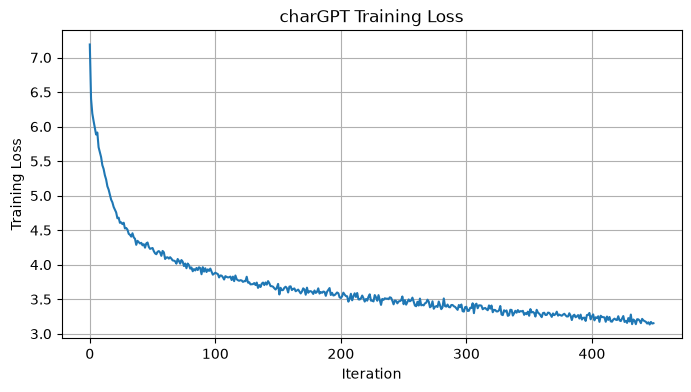

In [17]:
plt.figure(figsize=(8, 4))  # 새 그래프 캔버스를 만듦 (가로 8, 세로 4 인치 크기)
plt.plot(loss_history)      # loss_history 리스트를 순서대로 선 그래프로 그림 (x축은 자동으로 0,1,2,... 인덱스가 됨)
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("charGPT Training Loss")
plt.grid(True)   # 배경에 격자선을 표시해 값을 읽기 쉽게 함
plt.show()        # 그래프를 실제로 화면에 출력

## 10. 학습 후 생성 결과  [필수 이해] 학습 전후 생성 결과


In [18]:
model.eval()
with torch.no_grad():
    generated = model.generate(
        x_context, 500, temperature=TEMPERATURE, do_sample=True, top_k=TOP_K
    )[0]
# 7번 셀(학습 전)과 완전히 동일한 x_context에서 시작해서, 학습된 모델로 다시 생성 → 학습 전후를 공정하게 비교할 수 있음

after_training = "".join(train_dataset.itos[int(i)] for i in generated)
print(after_training)

오늘도 또 우리 수탉이 막 없다는 그 말고, 하나 사람에서 것이 그 일어나는 것은 그 사자를 못하고 들어 것이다. 
“아키코는 그렇게 것은 아니다고 어깨가 그 보면다.
그 아니면 그는 그 일어나는 아니다. 이런데 사람은 나그 사이 나는 것도리고 나서 하고,
"이 아래 어디를 나무 들어서 않다 다. 그는다시 아니 그 사람은 어떻게 아내려서 않았다. 그리고 없고 이 하지게 아내지만 지 다 않은 있겠더면 이것을 못한다.
그 아키코에 없고, 그렇게 아키코의 말 말이 그 것 말을 다시 못 것이다.
"아! 그렇고 그러나 그는 어지고 그 없고개를 들여 나무 않으니 그 없으면 이렇더 하였다. 이놈의 그러나 그 아키코에게 아내가 않으로 있는지 집 않고 있는가 아니 그 말이 것이다가 나이고 그만이 아내었다. 
“아무슨 이러나 나 나오지만, 하나 내의 말이 이러나 하고만 어느냐고 내 말이 않은 있었었다. 아니다. 아무러우는 나그는 소리를 다시라가 하며 그 집으며 나그 하였다. 그 사람에 나올 이놈에 다 그러내 아내에 하면 하고 


## 10-1. 학습 전·중간·후 비교  [필수 이해] 학습 전후 생성 결과


In [19]:
print("[학습 전]")
print(before_training)

for iteration, sample in generation_history.items():  # dict.items(): (key, value) 쌍을 순서대로 순회
    print("\n" + "=" * 80)
    print(f"[iter {iteration}]")
    print(sample)

print("\n" + "=" * 80)
print("[학습 후]")
print(after_training)

[학습 전]
﻿오늘도 또 우리 수탉이 막 푼편숴밑쏟맵벅십찌캔글끈꼴맵2왱꼼향싶탄괘끙멩릎냇락줴낼야놈똥흩깃맵핑정깃챈툰칫뽐적깔문칠정끈흙셨체개빵꿇잰빵끝윗둔숙깃십잰바떼왔빵꿇광탉빵얹랐째퍼덜기량릉째~퍼툇능상틀숙빵놨퐁낡잰탈분본퐁둔봬얘뻥얹랐한총“벤숙껑잰잰탈엌빌씻띄잰“퍼2몰째~홀칫헤녔빵웃바탈댁잰잰갯얘뻥한쪽순쪼싹빵웃홀던꿇빵꿇마빵빛잰끝﻿째순훌꿇퍼빵빵얹훅“벤잰2울맸끝앨빛“얹랐얘잰끝체끝잰체룽코얘퐁볶끝처굉심순﻿땅랐뻥덩떤빵흡윤'곡한줏체념빵빵씻굉꿇낟꿇눅“얹퍼2끝탈툇~덜홀퍼잰“곡풍섬승떤끅잰끝코씬캑“엮빵얹훅앗랐랐길떼홉속짹꿇눅끝냇핏앗툽얘터슴멀얘끝잰갯째털칫빵껑빵흡꿀석염코얘퐁냇퍼얹독퐁태퐁몇쭉잰펑총냇퍼석밖잰갯봬룽빵

[iter 50]
﻿오늘도 또 우리 수탉이 막 나 그 아이이 다
아 나 내다. 나 그 그 그를 이다.
하이 나 아다.고 그다. 아이 이 하에 이는 하이 아다, 아다. 그 내고 하. 한 아에, 아다. 아 그 
그 것리에, 내고 아 그 그다. 그 다.가 아이, 이다. 내고 그 하고 
나 나는 하고 아고 나, 그 그 내은, 하 내 한 하고다. 그 하 아다가 한 다
다
그 어지는 하다 하에 하이 내이 하에 


[iter 100]
﻿오늘도 또 우리 수탉이 막 아니 그리고 그 것이, 아니 그를 그를 일어서 사고 나서지 그 것 그러 내었다. 그 아서도 것이서 그는 아내는서 그리어서 내고 그리 내는 하는
그리게. 사리고 것 그 아 사어서 일이었게 못이 이는 그리 아내어 아다 그래는 아 내는 하어는 그리 것한 그 그를 이 사고 나 그는 나 일 사는 이 그러 그라. 그는 그 못 일으로 것이나서 이서가 이지 일으리고 그렇

[iter 150]
﻿오늘도 또 우리 수탉이 막 한다. 이 나 어 이 이 이 그라는 사라, 나 사는 그라는 것은 이 그는 그리를 하고 하게.”
“아니 아 것이는 아 이 어 사람에지도 이 그러나 이를
"그 하지, 아내 그러나 어 나, 그런 어서,
“아 내가 하는 그러니 이 것이는 그 그 이 아니 것이 아나서 그러내가지,
"아내고만 이 그러다."
“아키를 하여 아 하고 그리고 아주를 아내 그

## 11. 다음 문자 예측 한 단계 관찰

문맥 → forward → 마지막 위치 logits → softmax → 확률분포

In [20]:
probe = text[:16]
x = torch.tensor(
    [train_dataset.stoi[s] for s in probe], dtype=torch.long
)[None, ...].to(trainer.device)

model.eval()
with torch.no_grad():
    logits, _ = model(x)  # targets를 안 넘겼으므로 loss는 None → _로 버리고 logits만 사용

last_logits = logits[0, -1]                 # 마지막 위치 = 다음 문자 점수
# logits[0, -1] : 배치의 0번째 샘플, 문맥의 마지막(-1) 위치의 점수 벡터만 꺼냄 (다음에 올 문자를 예측하는 부분)
probs = F.softmax(last_logits, dim=-1)      # 점수 → 확률

topv, topi = torch.topk(probs, 5)  # 확률이 큰 순서로 5개의 (값, 인덱스)를 뽑음
print(f"문맥: {probe!r}")
# {probe!r} : f-string에서 !r은 repr()을 적용 — 문자열을 따옴표와 함께, 줄바꿈 등도 이스케이프해서 보여줌

print("\n다음 문자 확률 Top 5:")
for p, i in zip(topv, topi):  # topv와 topi를 같은 순서로 묶어서 동시에 순회
    print(f"  {train_dataset.itos[int(i)]!r} : {p.item():.3f}")
print(f"\n전체 {train_dataset.vocab_size}개 문자 확률의 합: {probs.sum().item():.4f}")
# softmax를 거친 확률은 항상 합이 1이 되어야 정상 — 검산용 출력

문맥: '\ufeff오늘도 또 우리 수탉이 막 '

다음 문자 확률 Top 5:
  '없' : 0.026
  '아' : 0.023
  '하' : 0.021
  '않' : 0.018
  '있' : 0.017

전체 1272개 문자 확률의 합: 1.0000


corpus에 없는 새 문장으로 같은 예측 수행


In [21]:
# corpus에 없는 새 문장으로도 예측해 보기 (본 적 없는 문맥)
probe2 = "장인님은 화가 나서 나를"
missing = [c for c in probe2 if c not in train_dataset.stoi]
# 리스트 컴프리헨션 + 조건문: probe2의 글자들 중 학습 vocab(stoi)에 없는 것만 골라 리스트로 모음
assert not missing, f"corpus에 없는 문자: {missing}"
# missing이 빈 리스트면 not missing은 True → assert 통과. 하나라도 있으면 에러 발생

x2 = torch.tensor(
    [train_dataset.stoi[s] for s in probe2], dtype=torch.long
)[None, ...].to(trainer.device)

with torch.no_grad():
    logits, _ = model(x2)
probs = F.softmax(logits[0, -1], dim=-1)

topv, topi = torch.topk(probs, 5)
print(f"문맥: {probe2!r}")
print("\n다음 문자 확률 Top 5:")
for p, i in zip(topv, topi):
    print(f"  {train_dataset.itos[int(i)]!r} : {p.item():.3f}")

문맥: '장인님은 화가 나서 나를'

다음 문자 확률 Top 5:
  ' ' : 0.989
  '\n' : 0.002
  ',' : 0.001
  '이' : 0.001
  '까' : 0.000
